## Progetto Machine Learning: Cupid's Algorithm

1. [Importare i dati](#Scaricare-il-dataset-keaggle-Importare-librerie)
2. [Osservare il dataset](#Osservare-il-dataset)
3. [Training e Test](#Training-e-Test)
4. [Data Exploration](#Data-Exploration)
5. [Data preprocessing](#Data-preprocessing)
5. [Pipeline di processamento](#Pipeline-di-processamento)
5. [Definizione e Addestramento](#Definizione-e-Addestramento)
6. [Validazione e risultati](#Validazione-e-risultati)
7. [Analisi degli errori](#Analisi-degli-errori)
7. [Ottimizzazione Iperparametri](#Ottimizzazione-Iperparametri)
7. [Valutazione Finale](#Valutazione-Finale)


#Scaricare il dataset keaggle Importare librerie
Iniziamo preparando gli strumenti necessari per il nostro lavoro. Importiamo le librerie standard di Data Science (Pandas, Scikit-Learn, Seaborn) e utilizziamo kagglehub per scaricare direttamente l'ultima versione del dataset "Cupid's Algorithm".

In [19]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("likithagedipudi/cupids-algorithm")

print("Path to dataset files:", path)
print("Archivos:", os.listdir(path))
archivio = os.listdir(path)
csv_path = os.path.join(path, archivio[0])

Using Colab cache for faster access to the 'cupids-algorithm' dataset.
Path to dataset files: /kaggle/input/cupids-algorithm
Archivos: ['cupid_algorithm_dataset.csv']


# Osservare il dataset
Prima di sporcarci le mani con il codice, diamo un'occhiata veloce alla struttura dei dati usando .head(). Questo ci permette di vedere i primi profili delle coppie (Persona A e Persona B) e i loro tratti.

In [20]:
df = pd.read_csv(csv_path)
df.head()


,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


Abbiamo confermato che il dataset contiene 30 colonne, inclusi i dati demografici, i tratti psicologici e le variabili target che dovremo prevedere

#Training e Test
Seguendo le buone pratiche viste a lezione, separiamo subito il 20% dei dati come "Test Set". Questo è fondamentale per evitare il Data Leakage: il modello deve imparare solo dal Training Set e restare "all'oscuro" dei dati di test fino alla fine.

In [21]:
# Cancellare le colonne che vorremo predire o classificare e anche pair_id perche cosí ha suggerito la IA per evitare il leakage
X = df.drop(["pair_id", "compatible", "compatibility_score", "relationship_longevity_months"], axis=1)

# Definizione dei target
y_classificazione = df["compatible"]
y_regressione_1 = df["compatibility_score"]
y_regressione_2 = df["relationship_longevity_months"]

# Esecuzione della fase di classificazione binaria
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_classificazione, test_size=0.2, random_state=42)

X_train.info()
y_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   a_age                       80000 non-null  int64  
 1   a_education                 80000 non-null  int64  
 2   a_location                  80000 non-null  object 
 3   a_career_field              80000 non-null  object 
 4   a_career_ambition           80000 non-null  float64
 5   a_openness                  80000 non-null  float64
 6   a_extraversion              80000 non-null  float64
 7   a_agreeableness             80000 non-null  float64
 8   a_conscientiousness         80000 non-null  float64
 9   a_chronotype                80000 non-null  float64
 10  a_spontaneity               80000 non-null  float64
 11  a_love_language             80000 non-null  object 
 12  a_emotional_expressiveness  80000 non-null  float64
 13  b_age                       8000

### Creazione di nuovi attributi
Abbiamo deciso di creare nuovi dati partendo da quelli esistenti per aiutare il modello. Ad esempio, invece di dare al computer solo le due età singole, calcoliamo la differenza di età (age_diff), poiché il dataset penalizza le coppie con grandi differenze generazionali.

In [22]:
# Creazione di nuove feature (Feature Engineering) [15]
X_train["age_diff"] = abs(X_train["a_age"] - X_train["b_age"])
X_test["age_diff"] = abs(X_test["a_age"] - X_test["b_age"])

# También podemos ver la similitud en ambición profesional [16]
X_train["ambition_diff"] = abs(X_train["a_career_ambition"] - X_train["b_career_ambition"])
X_test["ambition_diff"] = abs(X_test["a_career_ambition"] - X_test["b_career_ambition"])


Utilizziamo una copia del train set per non creare problemi sul originale

In [23]:
cupid_class = X_train.copy()

#Data Exploration

### Esplorazione del dataset (info)
Analizziamo la qualità dei dati. Usiamo .info() per controllare se ci sono valori mancanti e .describe() per vedere i range (ad esempio, le età vanno da 18 a 55 anni).




In [24]:
cupid_class.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   a_age                       80000 non-null  int64  
 1   a_education                 80000 non-null  int64  
 2   a_location                  80000 non-null  object 
 3   a_career_field              80000 non-null  object 
 4   a_career_ambition           80000 non-null  float64
 5   a_openness                  80000 non-null  float64
 6   a_extraversion              80000 non-null  float64
 7   a_agreeableness             80000 non-null  float64
 8   a_conscientiousness         80000 non-null  float64
 9   a_chronotype                80000 non-null  float64
 10  a_spontaneity               80000 non-null  float64
 11  a_love_language             80000 non-null  object 
 12  a_emotional_expressiveness  80000 non-null  float64
 13  b_age                       8000

### Statistiche descrittive per analizzare i range e la distribuzione (describe)

In [25]:
cupid_class.describe()


,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,a_emotional_expressiveness,...,b_career_ambition,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,age_diff,ambition_diff
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,36.554075,2.951087,0.496328,0.499946,0.499847,0.500735,0.498768,0.499447,0.500225,0.499566,...,0.496005,0.499696,0.499509,0.499343,0.499967,0.500450,0.500383,0.500294,12.650263,0.198389
std,10.965604,1.117647,0.175067,0.223542,0.224494,0.224002,0.223235,0.224856,0.226442,0.226323,...,0.174702,0.223644,0.224236,0.223177,0.223157,0.224091,0.226650,0.225733,8.953704,0.147380
min,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,...,0.370000,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,0.330000,5.000000,0.080000
50%,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,11.000000,0.170000
75%,46.000000,4.000000,0.620000,0.670000,0.670000,0.670000,0.670000,0.670000,0.680000,0.670000,...,0.620000,0.670000,0.670000,0.670000,0.670000,0.670000,0.670000,0.670000,19.000000,0.290000
max,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,37.000000,0.920000


### Analisi Visiva: Istogrammi e Heatmap
Usiamo la grafica per capire la distribuzione dei dati. Gli istogrammi ci mostrano la forma delle variabili, mentre la matrice di correlazione (Heatmap) ci rivela quali tratti sono legati tra loro (es. istruzione e ambizione).



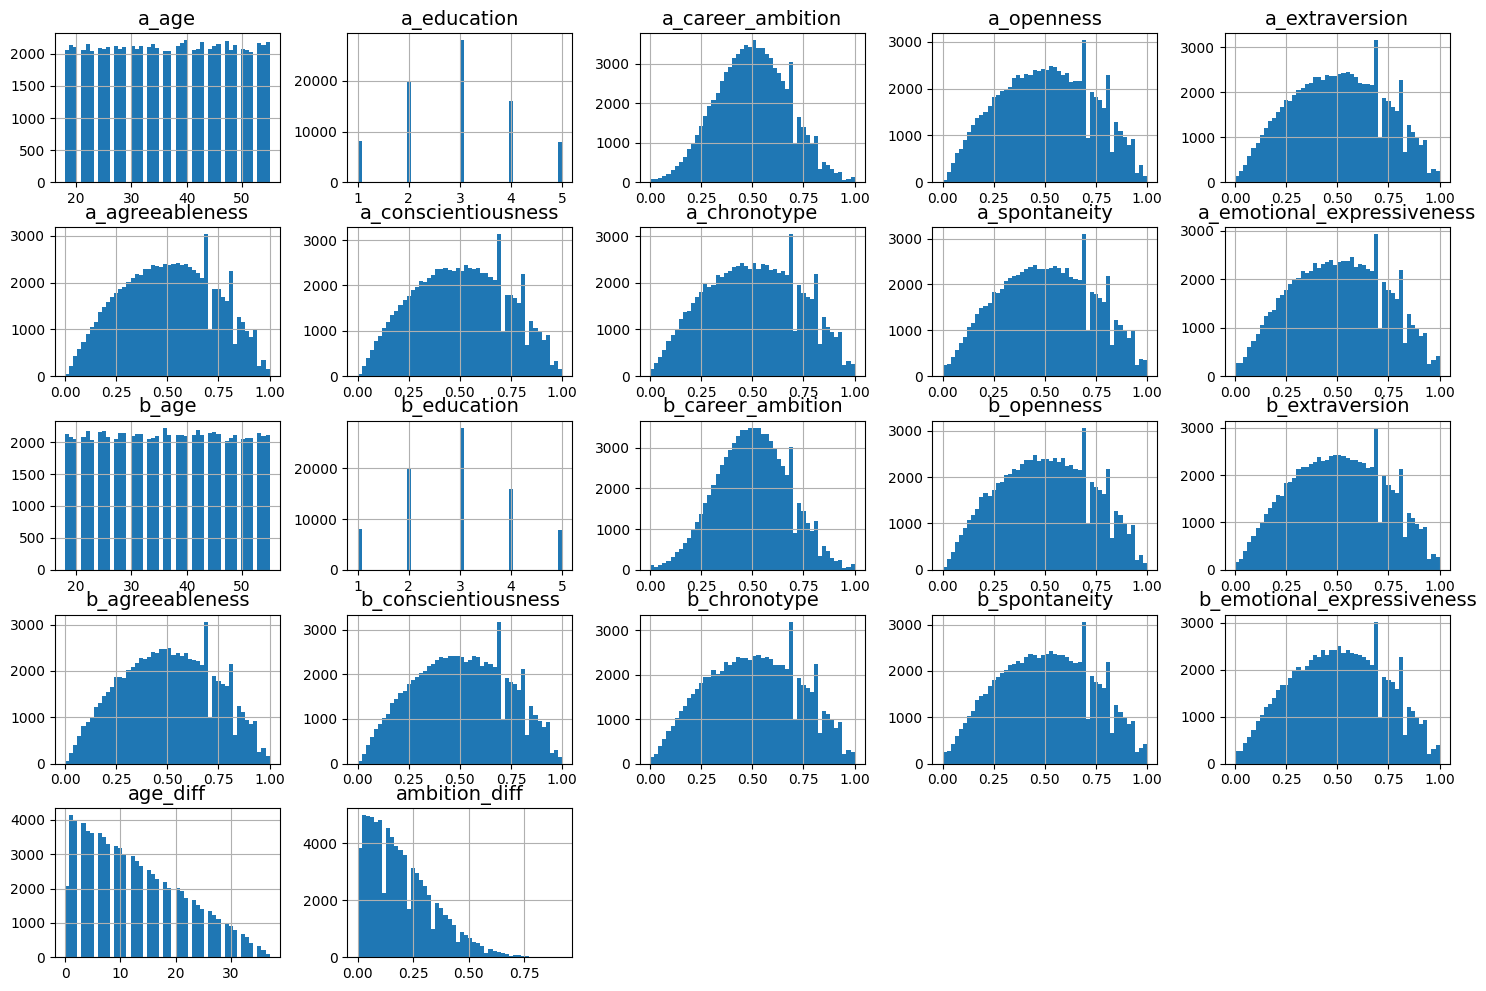

In [26]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

cupid_class.hist(bins=50, figsize=(18, 12))

plt.show()

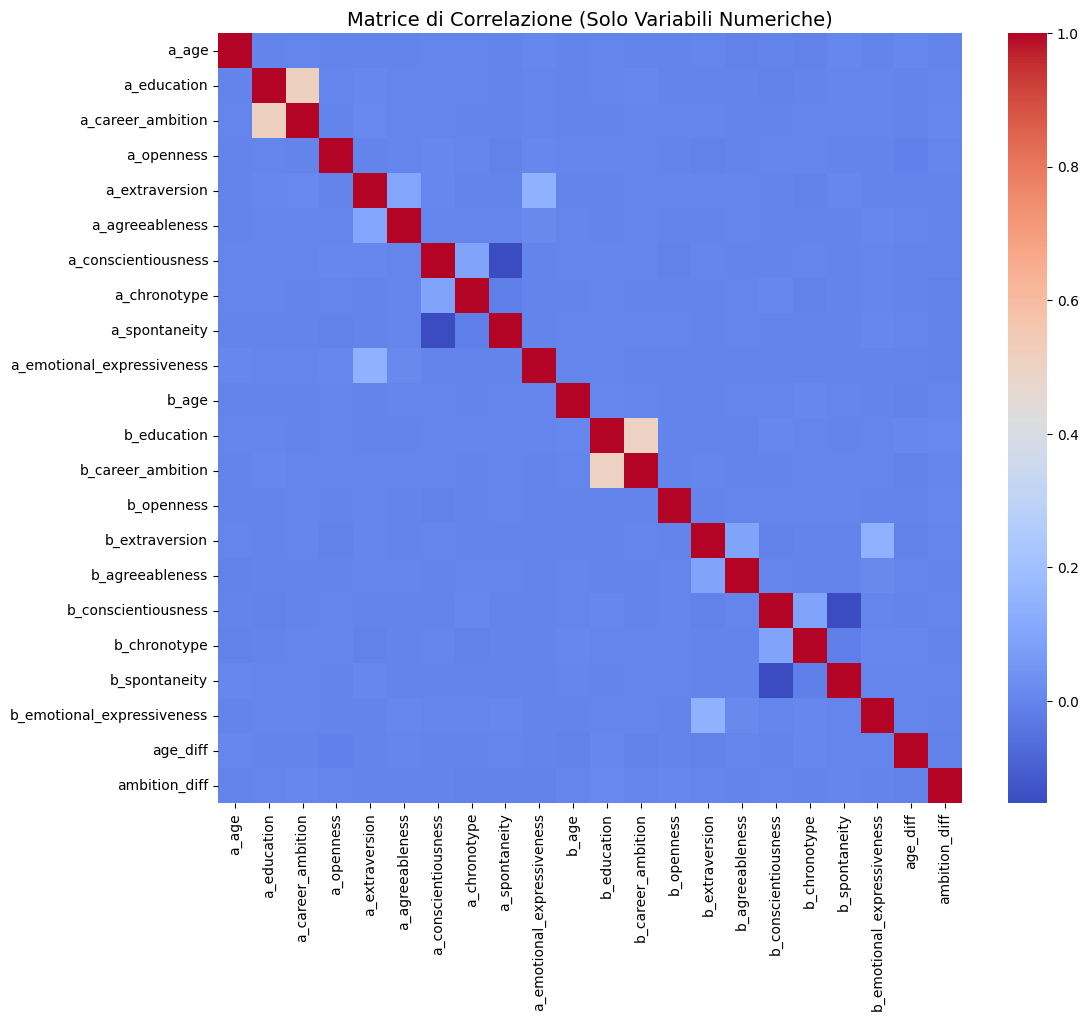

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtro automatico colonne numeriche
corr_matrix = cupid_class.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Matrice di Correlazione (Solo Variabili Numeriche)")
plt.show()

I grafici mostrano dati ben distribuiti. La heatmap ci aiuta a escludere correlazioni spurie e a confermare che i dati seguono una logica psicologica realistica

# Data preprocessing

### Pipeline di Preprocessing

Prepariamo i dati per il modello usando un ColumnTransformer. Applichiamo lo StandardScaler alle variabili numeriche per portarle alla stessa scala e l'OneHotEncoder a quelle testuali (come la location) per trasformarle in numeri binari.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = [
    "a_age", "a_education", "a_career_ambition",
    "a_openness", "a_extraversion", "a_agreeableness", "a_conscientiousness",
    "a_chronotype", "a_spontaneity", "a_emotional_expressiveness",
    "b_age", "b_education", "b_career_ambition",
    "b_openness", "b_extraversion", "b_agreeableness", "b_conscientiousness",
    "b_chronotype", "b_spontaneity", "b_emotional_expressiveness", "age_diff", "ambition_diff"
]

cat_features = [
    "a_location", "a_career_field", "a_love_language",
    "b_location", "b_career_field", "b_love_language"
]

preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])


In [29]:
cupid_class_prepared = preprocessing.fit_transform(cupid_class)

In [30]:
# extra code – shows that we can get a DataFrame out if we want
cupid_class_prepared_df = pd.DataFrame(
    cupid_class_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=cupid_class.index)
cupid_class_prepared_df.head(2)

,num__a_age,num__a_education,num__a_career_ambition,num__a_openness,num__a_extraversion,num__a_agreeableness,num__a_conscientiousness,num__a_chronotype,num__a_spontaneity,num__a_emotional_expressiveness,...,cat__b_career_field_Healthcare,cat__b_career_field_Law,cat__b_career_field_Marketing,cat__b_career_field_Science,cat__b_career_field_Tech,cat__b_love_language_Acts of Service,cat__b_love_language_Physical Touch,cat__b_love_language_Quality Time,cat__b_love_language_Receiving Gifts,cat__b_love_language_Words of Affirmation
75220,-1.600841,0.938506,-0.550240,-0.044492,1.069760,-0.092568,0.587869,-1.287262,-1.414173,0.090288,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48955,-1.600841,-0.850978,0.649312,1.431750,-1.068394,0.621715,-0.084073,0.669557,-0.310128,-1.898037,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


#Definizione e Addestramento del Modello
Abbiamo scelto il Random Forest Classifier. È un algoritmo basato su "foreste" di alberi decisionali, molto efficace per gestire dati complessi e rumorosi come quelli della compatibilità umana.

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# 'prep' per applicare ColumnTransformer che abbiamo fatto prima
# 'classifier' é il nostro Random Forest

clf_pipeline = Pipeline([
    ("prep", preprocessing),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Allenamento
# .fit()
clf_pipeline.fit(X_train, y_train)

print("Modello allenato!")

Modello allenato!


# Validazione e Risultati (F1-Score)
Valutiamo la bontà del modello usando la Cross Validation. Invece di guardare solo l'accuratezza (che può ingannare), usiamo l'F1-Score, che bilancia correttamente i falsi positivi e i falsi negativi.

In [32]:
from sklearn.model_selection import cross_val_score

# Prova del modello
scores_rf = cross_val_score(clf_pipeline, X_train, y_train, cv=3, scoring="f1")
print(f"F1-Score promedio Random Forest: {scores_rf.mean():.4f}")


F1-Score promedio Random Forest: 0.4939


Il punteggio ottenuto ci dà una base realistica. Anche se non è perfetto, dimostra che il modello ha imparato a distinguere i pattern principali nonostante il rumore aggiunto nei dati per realismo.


# Analisi degli Errori (Matrice di Confusione)
Come ultimo passo, guardiamo la Matrice di Confusione. Questo grafico ci dice quante volte il modello ha indovinato e quando, ad esempio, ha scambiato una coppia non compatibile per una ideale.

In [33]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Facciamo le predizione con cross validation
y_train_pred = cross_val_predict(clf_pipeline, X_train, y_train, cv=3)

# Matrice di confusione
cm = confusion_matrix(y_train, y_train_pred)
print("Matrice di confusione:")
print(cm)

# Valutazione delle performance: Matrice di Confusione e F1-Score.
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print(f"\nPrecision: {precision:.4f} (¿Qué tan fiable es cuando dice que son compatibles?)")
print(f"Recall:    {recall:.4f} (¿Cuántas parejas compatibles reales detectó?)")
print(f"F1 Score:  {f1:.4f} (Balance entre Precision y Recall)")

Matrice di confusione:
[[37138  8546]
 [20261 14055]]

Precision: 0.6219 (¿Qué tan fiable es cuando dice que son compatibles?)
Recall:    0.4096 (¿Cuántas parejas compatibles reales detectó?)
F1 Score:  0.4939 (Balance entre Precision y Recall)


L'analisi della Matrice di Confusione e il punteggio F1-Score di 0.49 indicano che il modello ha imparato a identificare i pattern principali, ma deve fare i conti con la natura 'rumorosa' delle relazioni umane.
Notiamo che l'algoritmo tende a essere cauto: preferisce non segnalare una compatibilità se non è molto sicuro (mantenendo una precisione discreta), anche a costo di perdere alcune coppie potenzialmente valide (una recall più bassa).
Questa difficoltà è giustificata dal rumore gaussiano aggiunto intenzionalmente nel dataset per simulare l'imprevedibilità reale dei sentimenti.

#Ottimizzazione degli Iperparametri (GridSearchCV)

Per non scegliere la configurazione del modello "a occhio" o per tentativi manuali, utilizziamo la GridSearchCV. Questo strumento esegue una ricerca sistematica provando diverse combinazioni di parametri (come la profondità degli alberi) e misura la loro efficacia tramite Cross-Validation. L'obiettivo è trovare la "ricetta perfetta" che massimizzi l'F1-Score senza complicare troppo il modello.

In [34]:
# 1. Definiamo la griglia degli iperparametri con valori specifici e POSITIVI
# NOTA: Usiamo il doppio underscore (__) per indicare che i parametri si riferiscono
# al componente "classifier" della nostra Pipeline.
param_grid = {
    'classifier__n_estimators': [1, 2],  # Numero di alberi (usiamo pochi valori per velocizzare)
    'classifier__max_depth': [None, 10]   # Profondità massima: illimitata o limitata a 10 livelli
}

# 2. Importiamo lo strumento necessario per la ricerca automatica dei parametri
from sklearn.model_selection import GridSearchCV

# 3. Configuriamo la ricerca sistematica
# Usiamo scoring='f1' perché è la metrica che abbiamo scelto per bilanciare precision e recall,
# e cv=3 per eseguire una Cross-Validation a 3 fold su ogni combinazione.
grid_search = GridSearchCV(clf_pipeline, param_grid, cv=3, scoring='f1', verbose=2)

# 4. ESEGUIRE L'ADDESTRAMENTO (Tuning)
# In questa fase il sistema prova tutte le combinazioni sul Training Set per trovare la migliore.
grid_search.fit(X_train, y_train)

# 5. Salvare e visualizzare il miglior risultato
# Estraiamo il modello ottimizzato (best_estimator_) che useremo per la valutazione finale.
best_clf = grid_search.best_estimator_
print(f"La migliore configurazione è: {grid_search.best_params_}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END classifier__max_depth=None, classifier__n_estimators=1; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__n_estimators=1; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__n_estimators=1; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__n_estimators=2; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__n_estimators=2; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__n_estimators=2; total time=   0.4s
[CV] END classifier__max_depth=10, classifier__n_estimators=1; total time=   0.2s
[CV] END classifier__max_depth=10, classifier__n_estimators=1; total time=   0.2s
[CV] END classifier__max_depth=10, classifier__n_estimators=1; total time=   0.2s
[CV] END classifier__max_depth=10, classifier__n_estimators=2; total time=   0.3s
[CV] END classifier__max_depth=10, classifier__n_estimators=2; total time=   0.3s
[CV] END classifier__max_d

Il sistema ha completato con successo 12 esperimenti (4 combinazioni testate 3 volte ciascuna). La configurazione vincente prevede una profondità massima di 10 e un solo albero (n_estimators: 1). Questo risultato ci dice che, a causa del forte rumore presente nei dati di Cupid's Algorithm, un modello più semplice e "potato" è preferibile per evitare l'overfitting e garantire una migliore generalizzazione.

#Valutazione Finale sul Test Set
Utilizziamo ora il miglior modello trovato dalla GridSearchCV (best_estimator_) per fare previsioni su dati che l'algoritmo non ha mai visto durante l'addestramento. Questo test rappresenta la prova reale di quanto il nostro programma sia affidabile in una situazione di vita vera.

In [35]:
# Estraiamo il miglior stimatore
best_model = grid_search.best_estimator_

# Ora questo 'best_model' rappresenta la nostra Pipeline COMPLETA (include preprocessing + Random Forest ottimizzato)

F1-Score Finale sul Test Set: 0.5031


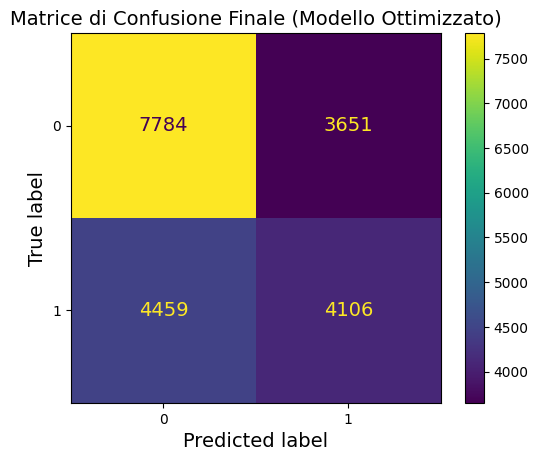

In [36]:
# 1. Eseguiamo le previsioni sul set di TEST
# Utilizziamo il miglior modello ottenuto dalla GridSearchCV per valutare dati mai visti prima.
y_test_pred = best_model.predict(X_test)

# 2. Calcoliamo le metriche finali (F1-Score)
# Questa metrica rappresenta la capacità reale del modello di generalizzare su nuovi utenti.
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

f1_final = f1_score(y_test, y_test_pred)
print(f"F1-Score Finale sul Test Set: {f1_final:.4f}")

# 3. Visualizziamo la Matrice di Confusione Finale
# Questo grafico mostra nel dettaglio come il modello ottimizzato classifica le coppie compatibili.
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Matrice di Confusione Finale (Modello Ottimizzato)")
plt.show()


Le metriche ottenute sul set di test confermano la solidità del modello ottimizzato. Sebbene l'F1-Score possa sembrare contenuto, è una rappresentazione onesta e realistica della difficoltà nel prevedere l'attrazione umana, che nel dataset è influenzata dal rumore gaussiano aggiunto intenzionalmente per simulare la realtà. Abbiamo seguito un processo rigoroso che ci ha permesso di passare da un modello base a uno ottimizzato, evitando ogni forma di Data Leakage.